# Exploration Notebook

**READ.ME**

This file helps you explore the functions of Brightway 2.5 in an intuitive way. So far, we have linked a background database with a simple foreground model in the previous sections of this repository. It is not a tutorial to go through, but a collection of usable code which you can adapt for your own projects. The goal is to make this Brightway 2.5 repository easy and reusable to use for your own projects.

## ⚙️ Step 1: Load Your Project

After ensuring all necessary packages are installed, you call the same project where you have installed and imported your databases. This happens through `bd.projects.set_current(Config.PROJECT_NAME)`

In [2]:
import importlib
import functions.utils as utils

importlib.reload(utils)
from functions.utils import Config

In [3]:
# This should be extended or reduced depending on the suggested functionalities

# basic imports from brightway
import bw2analyzer as ba
import bw2calc as bc
import bw2data as bd
import bw2io as bi
import bw2analyzer as bwa
from bw2data import methods
from bw2io import create_default_biosphere3
from functions.utils import Config
from functions.fun_visualisation import (
    apply_plot_style,
    plot_bar,
    plot_line,
    plot_scatter,
    plot_contribution_bar,
    plot_stacked,
    plot_pie,
)

# other relevant packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

In [4]:
# define a project where we install the databases and work in this script
bd.projects.set_current(Config.PROJECT_NAME)

## ⚙️ Step 2: Database overview

This section provides an overview of the background and foreground databases stored in the Brightway project.

In [5]:
bd.databases

Databases dictionary with 3 object(s):
	brightway_project_template
	ecoinvent-3.12-biosphere
	ecoinvent-3.12-consequential

In [6]:
bd.projects.current

'project_name'

In [7]:
ei_clca = bd.Database('ecoinvent-3.12-consequential')
ei_bio = bd.Database('ecoinvent-3.12-biosphere')
bafu2026 = bd.Database('bafu2026')
bonsai = bd.Database('BONSAI_V2.1.6')
bw_template = bd.Database('brightway_project_template')

## 🔍 Step 3: Searching the Database

Use the following `database.search('')` function to search for entries in your database

In [8]:
# search for activities in the database
ei_clca.search('electricity')

['electricity, from municipal waste incineration to generic market for electricity, medium voltage' (kilowatt hour, GR, None),
 'electricity, from municipal waste incineration to generic market for electricity, medium voltage' (kilowatt hour, MY, None),
 'electricity, from municipal waste incineration to generic market for electricity, medium voltage' (kilowatt hour, RS, None),
 'electricity, from municipal waste incineration to generic market for electricity, medium voltage' (kilowatt hour, IS, None),
 'electricity, from municipal waste incineration to generic market for electricity, medium voltage' (kilowatt hour, IE, None),
 'electricity, from municipal waste incineration to generic market for electricity, medium voltage' (kilowatt hour, SI, None),
 'electricity, from municipal waste incineration to generic market for electricity, medium voltage' (kilowatt hour, ID, None),
 'electricity, from municipal waste incineration to generic market for electricity, medium voltage' (kilowatt h

In [9]:
bw_template.search('ceramics')

['production of porcelain ceramics' (kilogram, RER, None)]

## 🧾 Step 4: Select a Process & Check Inventory

`define_name = database.get(name='', location='', unit='')` assigns the object "define_name" to the entry in the database that matches the search criteria.
    
You can directly export the inventory of the defined process to an Excel overview through `bi.export.excel.write_lci_excel(database.name, objs=[define_name], dirpath=Path.cwd())`.

In [10]:
# define a process and store in a object in the project
porcelain_ceramics = bw_template.get(name = 'production of porcelain ceramics', location = "RER", unit = 'kilogram')
sanitary_ceramics = ei_clca.get(name = 'sanitary ceramics production', location = "CH", unit = 'kilogram')

In [11]:
# export the LCI to Microsoft Excel in an overview format
bi.export.excel.write_lci_excel(bw_template.name, objs=[porcelain_ceramics], dirpath=Path.cwd())

'c:\\Users\\TimWeber\\repos_20LCA\\brightway_project_template\\project\\lci-brightway_project_template.xlsx'

In [12]:
# print the outputs of the process
list(sanitary_ceramics.production())

[Exchange: 1.0 kilogram 'sanitary ceramics production' (kilogram, CH, None) to 'sanitary ceramics production' (kilogram, CH, None)]

In [13]:
# print the consumers of a product
list(sanitary_ceramics.consumers())


[Exchange: 0.00841688555967824 kilogram 'sanitary ceramics production' (kilogram, CH, None) to 'market for sanitary ceramics' (kilogram, GLO, None)]

In [14]:
# (1) this is a way to print all exchanges of a process, there are multiple ways to extract this information
list(sanitary_ceramics.edges())


[Exchange: 1.0 kilogram 'sanitary ceramics production' (kilogram, CH, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: -0.000177 kilogram 'market for bilge oil' (kilogram, CH, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: 4e-09 unit 'ceramic factory construction' (unit, CH, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: 0.00303 kilogram 'market for chemical, inorganic' (kilogram, GLO, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: 0.425 kilogram 'market for clay' (kilogram, CH, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: 0.878 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, CH, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: 0.379 kilogram 'market for feldspar' (kilogram, GLO, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: -0.000102 kilogram 'market for hazardous waste, for undergrou

In [15]:
# (2) this is an other way to print all exchanges of a process
exchanges = sorted(sanitary_ceramics.exchanges(), key=lambda exc: exc['amount'], reverse=True)
for exc in exchanges:
    print(exc)

Exchange: 22.895 megajoule 'market for heat, district or industrial, natural gas' (megajoule, CH, None) to 'sanitary ceramics production' (kilogram, CH, None)
Exchange: 1.0 kilogram 'sanitary ceramics production' (kilogram, CH, None) to 'sanitary ceramics production' (kilogram, CH, None)
Exchange: 0.878 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, CH, None) to 'sanitary ceramics production' (kilogram, CH, None)
Exchange: 0.541 kilogram 'market for tap water' (kilogram, CH, None) to 'sanitary ceramics production' (kilogram, CH, None)
Exchange: 0.444 kilogram 'market for kaolin' (kilogram, GLO, None) to 'sanitary ceramics production' (kilogram, CH, None)
Exchange: 0.425 kilogram 'market for clay' (kilogram, CH, None) to 'sanitary ceramics production' (kilogram, CH, None)
Exchange: 0.379 kilogram 'market for feldspar' (kilogram, GLO, None) to 'sanitary ceramics production' (kilogram, CH, None)
Exchange: 0.251 kilogram 'market for silica sand' (kilogram, GLO, None

In [16]:
# (3) Alternative way to display all exchanges with the technosphere
list(sanitary_ceramics.technosphere())

[Exchange: -0.000177 kilogram 'market for bilge oil' (kilogram, CH, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: 4e-09 unit 'ceramic factory construction' (unit, CH, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: 0.00303 kilogram 'market for chemical, inorganic' (kilogram, GLO, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: 0.425 kilogram 'market for clay' (kilogram, CH, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: 0.878 kilowatt hour 'market for electricity, medium voltage' (kilowatt hour, CH, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: 0.379 kilogram 'market for feldspar' (kilogram, GLO, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: -0.000102 kilogram 'market for hazardous waste, for underground deposit' (kilogram, RER, None) to 'sanitary ceramics production' (kilogram, CH, None),
 Exchange: 22.895 megajoule 'market for he

In [17]:
# how to check the activity type of a process
check_activity_type = print(sanitary_ceramics["activity type"])

ordinary transforming activity


## 🌿 Step 4: Impact Assessment Methods

To calculate the Life Cycle Impacts the back- and foreground need to be linked to an assessment method. There is a large number of available methods that are pre-installed together with the ecoinvent biosphere flows in the 01_bw25_ecoinvent_importer script.

In [18]:
# here we will analyse the set of methods that are available as part of the background
list(bd.methods)[:5]

[('ecoinvent-3.12',
  'CML v4.8 2016 no LT',
  'acidification no LT',
  'acidification (incl. fate, average Europe total, A&B) no LT'),
 ('ecoinvent-3.12',
  'CML v4.8 2016 no LT',
  'climate change no LT',
  'global warming potential (GWP100) no LT'),
 ('ecoinvent-3.12',
  'CML v4.8 2016 no LT',
  'ecotoxicity: freshwater no LT',
  'freshwater aquatic ecotoxicity (FAETP inf) no LT'),
 ('ecoinvent-3.12',
  'CML v4.8 2016 no LT',
  'ecotoxicity: marine no LT',
  'marine aquatic ecotoxicity (MAETP inf) no LT'),
 ('ecoinvent-3.12',
  'CML v4.8 2016 no LT',
  'ecotoxicity: terrestrial no LT',
  'terrestrial ecotoxicity (TETP inf) no LT')]

In [19]:
# printing all methods that contain a specific keyword, e.g. "climate change"
climate_methods = [m for m in bd.methods if any("global warming potential" in str(part).lower() for part in m)]
for method in climate_methods:
    print(method)

('ecoinvent-3.12', 'CML v4.8 2016 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')
('ecoinvent-3.12', 'CML v4.8 2016', 'climate change', 'global warming potential (GWP100)')
('ecoinvent-3.12', 'Ecological Scarcity 2021 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')
('ecoinvent-3.12', 'Ecological Scarcity 2021', 'climate change', 'global warming potential (GWP100)')
('ecoinvent-3.12', 'EF v3.0 no LT', 'climate change no LT', 'global warming potential (GWP100) no LT')
('ecoinvent-3.12', 'EF v3.0 no LT', 'climate change: biogenic no LT', 'global warming potential (GWP100) no LT')
('ecoinvent-3.12', 'EF v3.0 no LT', 'climate change: fossil no LT', 'global warming potential (GWP100) no LT')
('ecoinvent-3.12', 'EF v3.0 no LT', 'climate change: land use and land use change no LT', 'global warming potential (GWP100) no LT')
('ecoinvent-3.12', 'EF v3.0', 'climate change', 'global warming potential (GWP100)')
('ecoinvent-3.12', 'EF v3.0', 'cl

In [20]:
# selecting the impact assessment methods that we want to use in our analysis
lcia_gwp100 = ('ecoinvent-3.12', 'EF v3.1', 'climate change', 'global warming potential (GWP100)')

## 📈 5. LCIA

This section shows how LCA results can be calculated quickly and be displayed as final score, process- and elementary flow based.

In [21]:
# Quick LCIA calculation
porcelain_ceramics_lca = porcelain_ceramics.lca(lcia_gwp100)
porcelain_ceramics_lca.score

0.6749479642849595

In [22]:
sanitary_ceramics_lca = sanitary_ceramics.lca(lcia_gwp100)
sanitary_ceramics_lca.score

3.08873074900671

In [23]:
# Elementary flows contribution analysis as summary table
porcelain_ceramics_lca.to_dataframe().pivot_table(index='row_name',values='amount',aggfunc='sum')

,amount
row_name,
"Carbon dioxide, fossil",0.524631
Dinitrogen monoxide,0.001083
"Methane, fossil",0.099280


In [24]:
characterized_inventory = porcelain_ceramics_lca.to_dataframe()

## 📊 6. Contribution analysis

There are different ways to analyse the contribution analysis in Brightway 2.5. Two ways are displayed below. The max_level and cutoff can be adjusted based on the level of detail you want from the analysis.

In [25]:
# One option to do a contribution analysis is to use the recursive calculation method
bwa.print_recursive_calculation(porcelain_ceramics,
lcia_method=lcia_gwp100,max_level=1,cutoff=0.005)

Fraction of score | Absolute score | Amount | Activity
0001 | 0.6749 |     1 | 'production of porcelain ceramics' (kilogram, RER, None)
  0.213 | 0.1439 | 0.5775 | 'market for kaolin' (kilogram, GLO, None)
  0.0219 | 0.01481 | 0.275 | 'market for feldspar' (kilogram, GLO, None)
  0.017 | 0.01148 | 0.2475 | 'market for silica sand' (kilogram, GLO, None)
  0.352 | 0.2375 | 1.028 | 'market group for electricity, high voltage' (kilowatt hour, RER, None)
  0.35 | 0.2363 | 0.4507 | 'market group for natural gas, high pressure' (cubic meter, Europe without Switzerland, None)
  0.0459 | 0.03096 | 1.25e-10 | 'packaging glass factory construction' (unit, RER, None)


In [26]:
# One option to do a contribution analysis is to use the recursive calculation method
bwa.print_recursive_calculation(sanitary_ceramics,
lcia_method=lcia_gwp100,max_level=1,cutoff=0.005)

Fraction of score | Absolute score | Amount | Activity
0001 | 3.089 |     1 | 'sanitary ceramics production' (kilogram, CH, None)
  0.0308 | 0.09502 | 4e-09 | 'ceramic factory construction' (unit, CH, None)
  0.0582 | 0.1798 | 0.878 | 'market for electricity, medium voltage' (kilowatt hour, CH, None)
  0.00661 | 0.02041 | 0.379 | 'market for feldspar' (kilogram, GLO, None)
  0.851 | 2.629 | 22.89 | 'market for heat, district or industrial, natural gas' (megajoule, CH, None)
  0.0358 | 0.1106 | 0.444 | 'market for kaolin' (kilogram, GLO, None)
  0.00572 | 0.01766 | 0.125 | 'market for stucco' (kilogram, GLO, None)


In [27]:
# Another option is to use the recursive calculation to an object, which returns a DataFrame
porcelain_ceramics_ca = bwa.utils.recursive_calculation_to_object(porcelain_ceramics,
                                          lcia_method=lcia_gwp100,
                                          max_level=1,
                                          cutoff=0.005,
                                          as_dataframe=True,
                                          )
porcelain_ceramics_ca

,label,parent,score,fraction,amount,name,key
0,root,NaN,0.674948,1.000000,1.000000e+00,production of porcelain ceramics,"(brightway_project_template, 18cf9c1477062c6c3..."
1,root_a,root,0.143875,0.213165,5.775000e-01,market for kaolin,"(ecoinvent-3.12-consequential, 1439cf096908796..."
2,root_b,root,0.014809,0.021941,2.750000e-01,market for feldspar,"(ecoinvent-3.12-consequential, 38b779a9752caf3..."
3,root_c,root,0.011482,0.017011,2.475000e-01,market for silica sand,"(ecoinvent-3.12-consequential, 42fbf9819e03152..."
4,root_d,root,0.237512,0.351897,1.027700e+00,"market group for electricity, high voltage","(ecoinvent-3.12-consequential, d2b2433d24c54e8..."
5,root_e,root,0.236306,0.350110,4.506667e-01,"market group for natural gas, high pressure","(ecoinvent-3.12-consequential, b575f5bf391b074..."
6,root_f,root,0.030963,0.045874,1.250000e-10,packaging glass factory construction,"(ecoinvent-3.12-consequential, 85bab1c73cbd732..."


In [28]:
# Another option is to use the recursive calculation to an object, which returns a DataFrame
sanitary_ceramics_ca = bwa.utils.recursive_calculation_to_object(sanitary_ceramics,
                                          lcia_method=lcia_gwp100,
                                          max_level=1,
                                          cutoff=0.005,
                                          as_dataframe=True,
                                          )
sanitary_ceramics_ca

,label,parent,score,fraction,amount,name,key
0,root,NaN,3.088731,1.000000,1.000000e+00,sanitary ceramics production,"(ecoinvent-3.12-consequential, 865d5e249bfa376..."
1,root_b,root,0.095020,0.030763,4.000000e-09,ceramic factory construction,"(ecoinvent-3.12-consequential, 69852bbafe615ba..."
2,root_e,root,0.179841,0.058225,8.780000e-01,"market for electricity, medium voltage","(ecoinvent-3.12-consequential, 045521b5763d77d..."
3,root_f,root,0.020410,0.006608,3.790000e-01,market for feldspar,"(ecoinvent-3.12-consequential, 38b779a9752caf3..."
4,root_h,root,2.629249,0.851239,2.289500e+01,"market for heat, district or industrial, natur...","(ecoinvent-3.12-consequential, 2fd188948680f30..."
5,root_j,root,0.110616,0.035813,4.440000e-01,market for kaolin,"(ecoinvent-3.12-consequential, 1439cf096908796..."
6,root_o,root,0.017659,0.005717,1.250000e-01,market for stucco,"(ecoinvent-3.12-consequential, 631a17914a1f2ba..."


## 🎨 7. Plot Contribution analysis graphs

In [29]:
# Filter out the parent processes that are not relevant for the contribution analysis
porcelain_ceramics_ca = porcelain_ceramics_ca.dropna(subset='parent')
sanitary_ceramics_ca = sanitary_ceramics_ca.dropna(subset='parent')

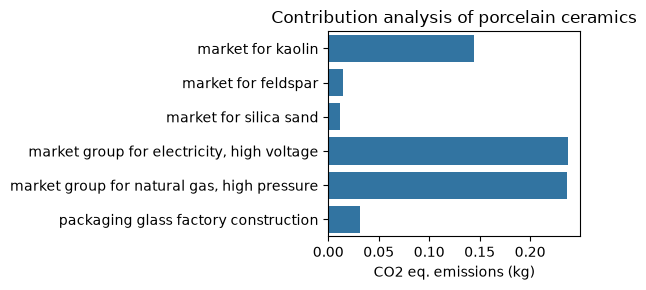

In [30]:
# First, we plot the contribution analysis for the brigthway ceramics production process
f, ax = plt.subplots(figsize=(6, 3))
sns.barplot(y='name', x='score', data=porcelain_ceramics_ca, ax=ax)
ax.set(
    title='Contribution analysis of porcelain ceramics',
    xlabel='CO2 eq. emissions (kg)',
    ylabel='')
plt.tight_layout()
plt.show()


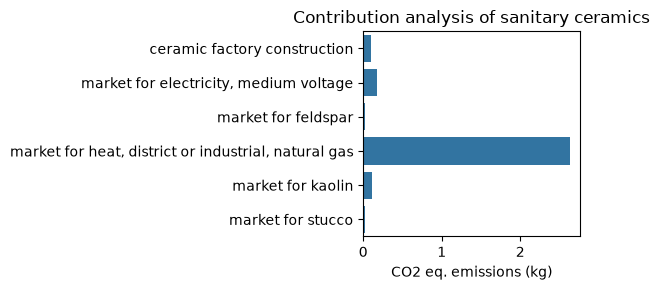

In [31]:
# First, we plot the contribution analysis for the brigthway ceramics production process
f, ax = plt.subplots(figsize=(6, 3))
sns.barplot(y='name', x='score', data=sanitary_ceramics_ca, ax=ax)
ax.set(
    title='Contribution analysis of sanitary ceramics',
    xlabel='CO2 eq. emissions (kg)',
    ylabel='')
plt.tight_layout()
plt.show()


In [32]:
# This is an example for combining two results in one table
combined_df = pd.concat([porcelain_ceramics_ca.set_index('name').score,sanitary_ceramics_ca.set_index('name').score],
                        keys=['Porcelain ceramics','Sanitary ceramics'],
                        names=['activity','contributor'])
combined_df

activity            contributor                                         
Porcelain ceramics  market for kaolin                                       0.143875
                    market for feldspar                                     0.014809
                    market for silica sand                                  0.011482
                    market group for electricity, high voltage              0.237512
                    market group for natural gas, high pressure             0.236306
                    packaging glass factory construction                    0.030963
Sanitary ceramics   ceramic factory construction                            0.095020
                    market for electricity, medium voltage                  0.179841
                    market for feldspar                                     0.020410
                    market for heat, district or industrial, natural gas    2.629249
                    market for kaolin                                       0

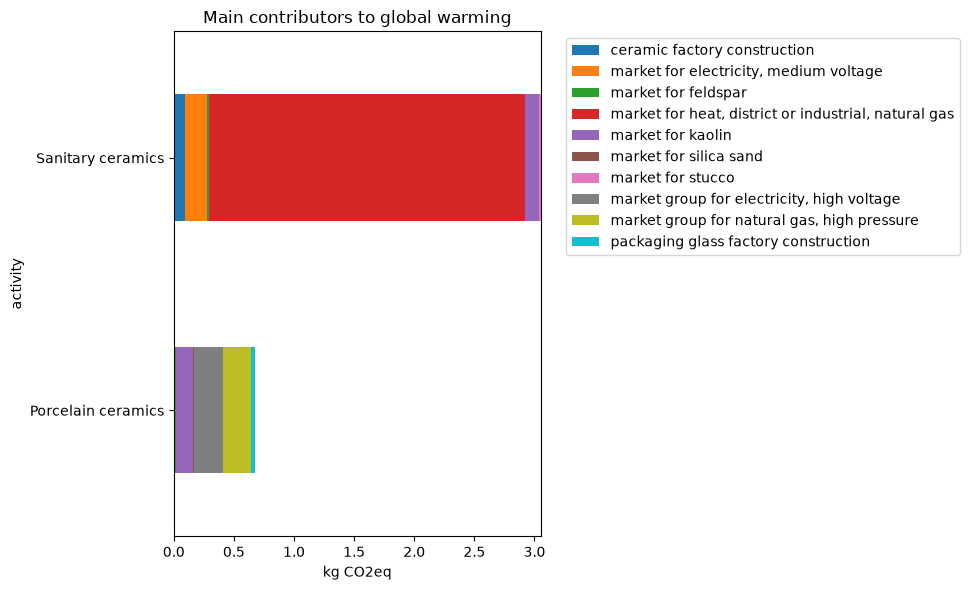

In [33]:
ax = combined_df.unstack().plot.barh(
    stacked=True,
    title='Main contributors to global warming',
    xlabel='kg CO2eq',
    figsize=(10,6)
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # moves legend outside
plt.tight_layout()
plt.show()

## 🎨 8. Visualisation with Brand Identity

A final tool offered in this repository is the creation of branded result visualisations. 

In [35]:
import importlib
import functions.utils as utils
import functions.fun_visualisation as vis

importlib.reload(utils)
importlib.reload(vis)

<module 'functions.fun_visualisation' from 'C:\\Users\\TimWeber\\repos_20LCA\\brightway_project_template\\functions\\fun_visualisation.py'>

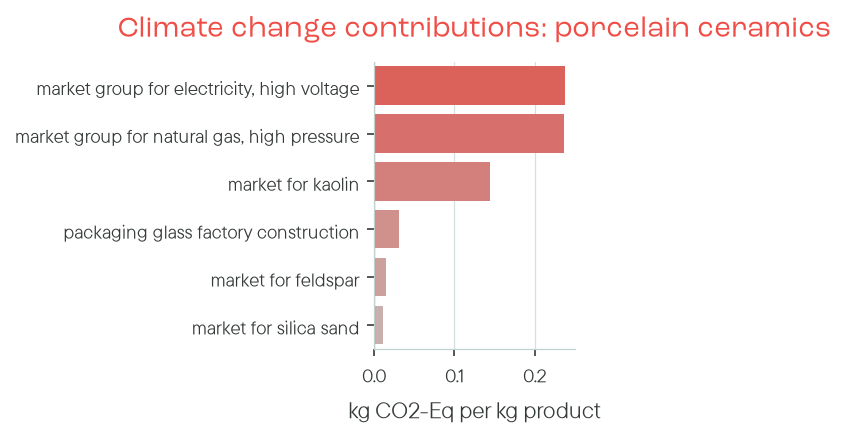

In [43]:
impact_unit = bd.methods[lcia_gwp100]["unit"]

fig, ax = plot_contribution_bar(
    porcelain_ceramics_ca,
    title="Climate change contributions: porcelain ceramics",
    unit=f"{impact_unit} per kg product",
    top_n=10,
    figsize=(4, 3),
)

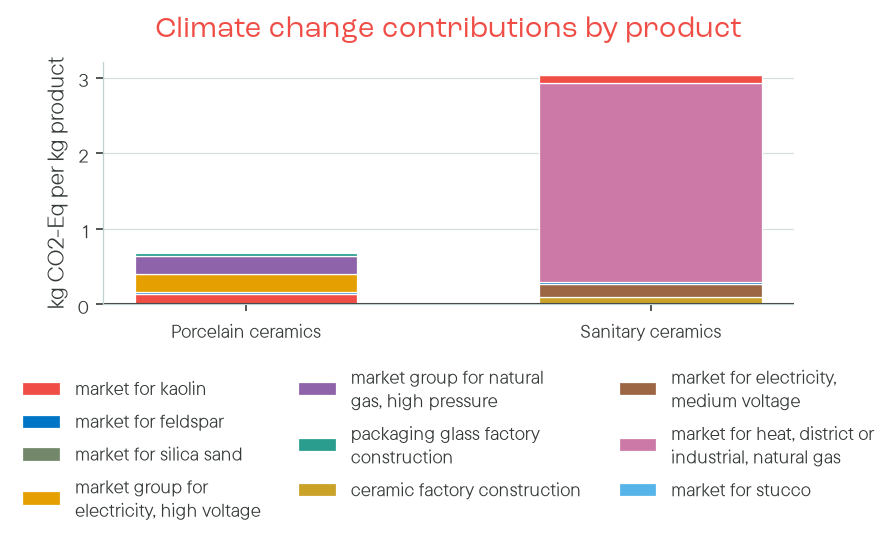

In [45]:
fig_comparison, ax, color_map = plot_stacked(
    porcelain_ceramics_ca,
    sanitary_ceramics_ca,
    labels=["Porcelain ceramics", "Sanitary ceramics"],
    title="Climate change contributions by product",
    unit=f"{impact_unit} per kg product",
    figsize=(6, 5),
)